# Mamba-JEPA Diagnostics: adjudicating the smoke-eval anomaly

Audit companion for `mamba_jepa_v1_hd_vicreg` (`final.pt`, step 78,200). The static audit
(`reports/mamba_jepa_audit.md`) identified `othello_research/evaluation/legal_moves.py::_amp_context`
(lines 71–75) as the prime suspect: it **hardcodes fp16 autocast** for every legal-move evaluation,
while the Mamba residual stream exceeds the fp16 range (max|act| ≈ 5e5 ≫ 65504). All other smoke-eval
consumers ran in bf16.

Sections (each self-contained and skippable via the `RUN_*` flags):

- **A. Training-curve audit** — VICReg components for the Mamba run vs the Transformer v1-HD reference; NaN scan. *(H2 check)*
- **A2. Precision sweep** — per-layer max|activation| and finiteness under fp32/bf16/fp16 on the CUDA kernel. *(mechanism)*
- **B0. Head-eval precision repro** — the saved heads through the unmodified evaluator under inherited-fp16 vs forced-bf16/fp32. *(H1 confirmation + corrected numbers)*
- **B. Objective-solved test** — nearest length-1 target prototype classification. *(H1 vs H2 decision)*
- **C. Random-init reservoir control** — exact linear board-probe pipeline on random Mamba + random Transformer vs trained numbers. *(reservoir check)*
- **D. Head retrain on the hook path** — fresh heads at L7/L8/L15 with MLP LR sweep + input-LayerNorm variant. *(H1/H3 + anomaly C)*
- **E. Summary regeneration** — headline tables re-emitted from the raw JSON, bypassing the original generator.

Local (CPU) findings this notebook re-verifies on the real `mamba_ssm` kernel: fp32 re-eval of the saved
heads gave **94.3% (linear) / 94.0% (MLP) top-1 legal** on 64 games, and the reported 14.39% reconciles
exactly with an all-NaN argmax from position 1 onward.


## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Configure project, data, run

In [ ]:
from pathlib import Path
import os, subprocess, sys, yaml

PROJECT_ROOT = Path('/content/drive/Othercomputers/MyLaptop/Master_Thesis_Code')
ARTIFACT_ROOT = Path('/content/drive/MyDrive/Master_Thesis_Artifacts')
DATA_ROOT = ARTIFACT_ROOT / 'data'
RUNS_DIR = ARTIFACT_ROOT / 'runs' / 'Mamba-JEPA'
CONFIGS_DIR = PROJECT_ROOT / 'configs'

assert PROJECT_ROOT.exists(), PROJECT_ROOT
assert (PROJECT_ROOT / 'othello_research' / 'diagnostics' / 'mamba_jepa_audit.py').exists(), (
    'Sync the laptop working tree to Drive first: the diagnostics module is missing.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', str(PROJECT_ROOT)], check=True)
os.chdir(PROJECT_ROOT)

import importlib.util
if importlib.util.find_spec('mamba_ssm') is None:
    print('installing mamba_ssm...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-U', 'packaging', 'ninja'], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'mamba-ssm[causal-conv1d]',
                    '--no-build-isolation'], check=True)

CONFIG_NAME = 'mamba_jepa_v5_hd_infonce.yml'
CHECKPOINT_NAME = 'final.pt'
TRANSFORMER_REFERENCE_RUN = ARTIFACT_ROOT / 'runs' / 'jepa_v5_contrastive_prefix_mask_hard_disjoint'

# Section toggles — each section is independent.
RUN_A  = True   # training-curve audit (fast, CPU-only)
RUN_A2 = True   # precision sweep (fast)
RUN_B0 = True   # head-eval precision repro (the decisive H1 check)
RUN_B  = False   # objective-solved test
RUN_C  = True   # random-init reservoir control
RUN_D  = True   # hook-path head retrain (slowest section)
RUN_E  = True   # summary regeneration (fast)

EVAL_TRAIN_CHUNKS = 20
LEGAL_EVAL_GAMES = 5000
SEED = 42

with open(CONFIGS_DIR / CONFIG_NAME, encoding='utf-8') as f:
    EXPERIMENT_CONFIG = yaml.safe_load(f)
BOARD_SIZE = int(EXPERIMENT_CONFIG['data']['board_size'])
JEPA_RUN_NAME = EXPERIMENT_CONFIG['experiment']['name']
N_TRAIN_CHUNKS = int(EXPERIMENT_CONFIG['data']['li_split_train_chunks'])

DATA_DIR = DATA_ROOT / f'othello_{BOARD_SIZE}x{BOARD_SIZE}'
JEPA_OUT_DIR = RUNS_DIR / JEPA_RUN_NAME
SMOKE_EVAL_DIR = JEPA_OUT_DIR / 'smoke_eval'
DIAG_DIR = JEPA_OUT_DIR / 'diagnostics'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

all_chunks = sorted(DATA_DIR.glob('*.pickle'))
train_chunks = all_chunks[:EVAL_TRAIN_CHUNKS]
val_chunks = all_chunks[N_TRAIN_CHUNKS:]
assert train_chunks and val_chunks
print('run:', JEPA_RUN_NAME, '| train chunks:', len(train_chunks), '| val chunks:', len(val_chunks))

run: mamba_jepa_v5_hd_infonce | train chunks: 20 | val chunks: 38


## 3. Load and freeze the trained Mamba-JEPA; log versions

In [19]:
import json, random, warnings
import numpy as np
import torch
import torch.nn as nn

import othello_research.training.train_mamba_jepa as tjm
import othello_research.diagnostics.mamba_jepa_audit as audit
import importlib
importlib.reload(audit)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

VERSIONS = audit.collect_versions()
print(json.dumps(VERSIONS, indent=2))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load(JEPA_OUT_DIR / CHECKPOINT_NAME, map_location=device, weights_only=False)
bad = [k for k, v in ckpt['model'].items()
       if torch.is_tensor(v) and v.is_floating_point() and not torch.isfinite(v).all()]
assert not bad, f'non-finite checkpoint tensors: {bad}'

jepa_model, jepa_cfg = tjm.build_model_from_checkpoint(ckpt)
jepa_model.load_state_dict(ckpt['model'])
jepa_model.to(device).eval()
for p in jepa_model.parameters():
    p.requires_grad_(False)
context_encoder = jepa_model.context_encoder
print('checkpoint step:', ckpt.get('step'), '| games seen:', f"{ckpt.get('games_seen', 0):,}")

DIAG_RESULTS = {'metadata': {'run': JEPA_RUN_NAME, 'checkpoint': CHECKPOINT_NAME,
                             'step': ckpt.get('step'), 'versions': VERSIONS}}

{
  "python": "3.12.13",
  "torch": "2.11.0+cu128",
  "cuda_available": "True",
  "cuda_version": "12.8",
  "device_name": "NVIDIA RTX PRO 6000 Blackwell Server Edition",
  "mamba_ssm": "2.3.2.post1"
}
checkpoint step: 54591 | games seen: 19,999,840


## A. Training-curve audit

Decision rule: if the Mamba invariance term never descends comparably to the Transformer's,
or shows NaN/spikes, that supports **H2**. (Local pre-check: both runs plateau at
inv ≈ 0.10–0.12 with var_loss ≈ 0.7 — the Mamba is *not* worse than the Transformer reference.)

In [ ]:
if RUN_A:
    import pandas as pd
    import matplotlib.pyplot as plt

    mamba_df = pd.read_csv(JEPA_OUT_DIR / 'metrics.csv')
    tf_path = TRANSFORMER_REFERENCE_RUN / 'metrics.csv'
    tf_df = pd.read_csv(tf_path) if tf_path.exists() else None

    obj_cols = ['inv_loss', 'var_loss', 'cov_loss', 'z_pred_std', 'z_tgt_std', 'cos_sim_offdiag']
    n_bad = int(mamba_df[obj_cols].isna().sum().sum())
    print(f'NaN cells in Mamba objective columns: {n_bad} / {len(mamba_df) * len(obj_cols)}')

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, col in zip(axes.flat, obj_cols):
        ax.plot(mamba_df['step'], mamba_df[col], label='mamba_v1_hd', lw=1.5)
        if tf_df is not None and col in tf_df:
            ax.plot(tf_df['step'], tf_df[col], label='transformer_v1_hd', lw=1.5)
        if col in ('z_pred_std', 'z_tgt_std'):
            ax.axhline(1.0, color='gray', ls='--', lw=0.8, label='VICReg gamma=1.0')
        ax.set_title(col); ax.set_xlabel('step'); ax.legend(fontsize=8)
    plt.suptitle('VICReg components: Mamba vs Transformer v1-HD'); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6, 3))
    plt.plot(mamba_df['step'], mamba_df['lr']); plt.title('LR schedule (Mamba run)'); plt.show()

    last = mamba_df.tail(10).mean(numeric_only=True)
    tf_last = tf_df.tail(10).mean(numeric_only=True) if tf_df is not None else None
    print(f"Mamba last-10: inv={last['inv_loss']:.4f} var={last['var_loss']:.4f} "
          f"cov={last['cov_loss']:.4f} z_tgt_std={last['z_tgt_std']:.4f}")
    if tf_last is not None:
        print(f"Transformer last-10: inv={tf_last['inv_loss']:.4f} var={tf_last['var_loss']:.4f} "
              f"cov={tf_last['cov_loss']:.4f} z_tgt_std={tf_last['z_tgt_std']:.4f}")
    comparable = tf_last is None or last['inv_loss'] <= tf_last['inv_loss'] * 1.5
    verdict = 'PASS' if (n_bad == 0 and comparable) else 'FAIL'
    DIAG_RESULTS['A_training_curves'] = {'nan_cells': n_bad, 'mamba_last10_inv': float(last['inv_loss']),
        'transformer_last10_inv': None if tf_last is None else float(tf_last['inv_loss']), 'verdict': verdict}
    print(f"VERDICT: {verdict} — " + ('no NaN/spikes; invariance term comparable to the Transformer reference; '
          'does NOT support H2' if verdict == 'PASS' else 'training-curve anomaly; supports H2'))

KeyError: "['inv_loss', 'var_loss', 'cov_loss', 'z_pred_std', 'z_tgt_std'] not in index"

objective family: infonce
objective columns: ['infonce_loss', 'positive_accuracy', 'diag_accuracy', 'z_std', 'c_std', 'p_std', 'cos_sim_offdiag', 'logit_std', 'dedup_fraction']
Non-finite/missing training cells: 0 / 1800 (0.000%)


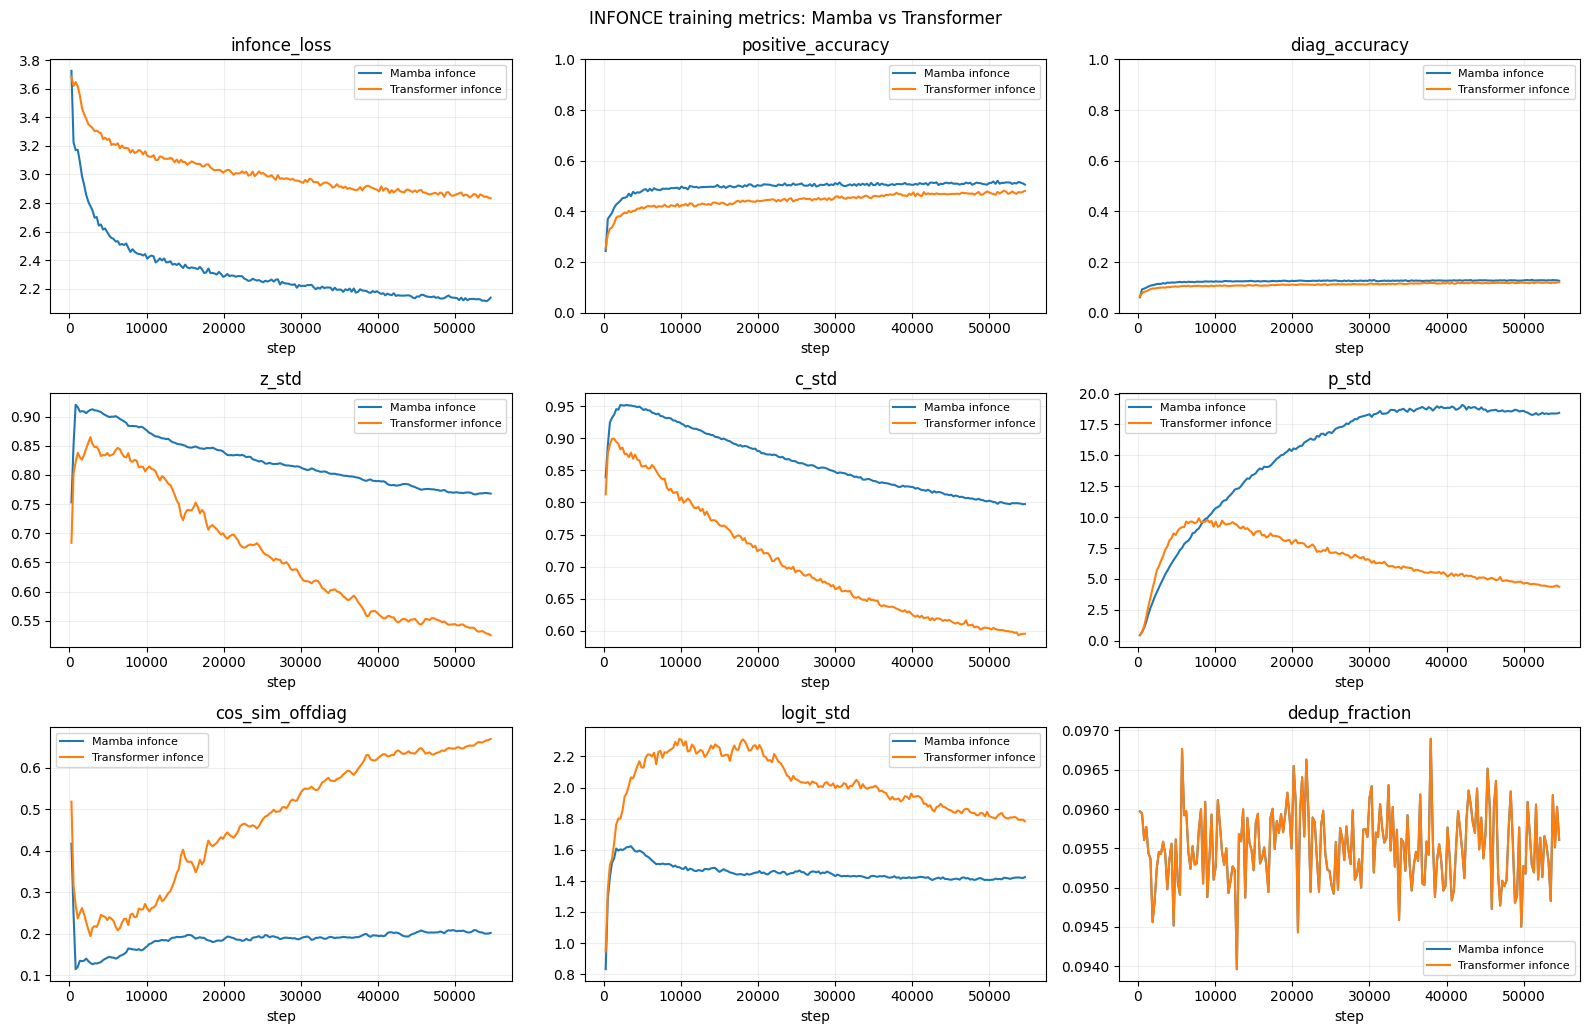

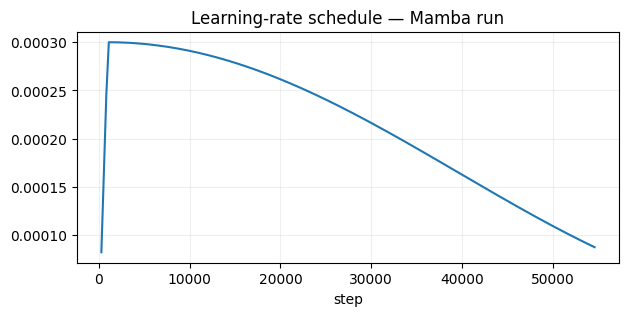


Mamba last-10 means
  infonce_loss            : 2.123311
  positive_accuracy       : 0.511755
  diag_accuracy           : 0.127885
  z_std                   : 0.768101
  c_std                   : 0.798213
  p_std                   : 18.382019
  cos_sim_offdiag         : 0.203640
  logit_std               : 1.418909
  dedup_fraction          : 0.095543

Transformer last-10 means
  infonce_loss            : 2.848126
  positive_accuracy       : 0.474830
  diag_accuracy           : 0.118638
  z_std                   : 0.531889
  c_std                   : 0.597197
  p_std                   : 4.421458
  cos_sim_offdiag         : 0.661195
  logit_std               : 1.799834
  dedup_fraction          : 0.095543

VERDICT: PASS — InfoNCE metrics are finite and the target/prediction representations have nonzero variance.


In [ ]:
if RUN_A:
    import math
    import pandas as pd
    import matplotlib.pyplot as plt

    mamba_df = pd.read_csv(JEPA_OUT_DIR / "metrics.csv")

    tf_path = TRANSFORMER_REFERENCE_RUN / "metrics.csv"
    tf_df = pd.read_csv(tf_path) if tf_path.exists() else None

    is_vicreg = "inv_loss" in mamba_df.columns
    is_infonce = "infonce_loss" in mamba_df.columns

    if is_vicreg:
        objective_family = "vicreg"
        obj_cols = [
            "inv_loss",
            "var_loss",
            "cov_loss",
            "z_pred_std",
            "z_tgt_std",
            "cos_sim_offdiag",
        ]
    elif is_infonce:
        objective_family = "infonce"
        obj_cols = [
            "infonce_loss",
            "positive_accuracy",
            "diag_accuracy",
            "z_std",
            "c_std",
            "p_std",
            "cos_sim_offdiag",
            "positive_sim",
            "negative_sim",
            "logit_std",
            "dedup_fraction",
        ]
    else:
        raise RuntimeError(
            "Unknown metrics schema. Available columns:\n"
            + "\n".join(mamba_df.columns)
        )

    # Keep only columns that genuinely exist in this run.
    obj_cols = [col for col in obj_cols if col in mamba_df.columns]

    print("objective family:", objective_family)
    print("objective columns:", obj_cols)

    # Count non-finite training values. Validation NaNs may be expected on
    # chunks where validation was not scheduled, so they are not included.
    numeric = mamba_df[obj_cols].apply(pd.to_numeric, errors="coerce")
    finite_mask = numeric.notna()

    n_bad = int((~finite_mask).sum().sum())
    n_total = int(numeric.size)

    print(
        f"Non-finite/missing training cells: "
        f"{n_bad} / {n_total} ({n_bad / max(1, n_total):.3%})"
    )

    n_cols = 3
    n_rows = math.ceil(len(obj_cols) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 3.5 * n_rows),
        squeeze=False,
    )

    for ax, col in zip(axes.flat, obj_cols):
        ax.plot(
            mamba_df["step"],
            mamba_df[col],
            label=f"Mamba {objective_family}",
            linewidth=1.5,
        )

        if tf_df is not None and col in tf_df.columns:
            ax.plot(
                tf_df["step"],
                tf_df[col],
                label=f"Transformer {objective_family}",
                linewidth=1.5,
            )

        if objective_family == "vicreg" and col in {
            "z_pred_std",
            "z_tgt_std",
        }:
            ax.axhline(
                1.0,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                label="VICReg gamma=1",
            )

        if objective_family == "infonce" and col in {
            "positive_accuracy",
            "diag_accuracy",
            "contrastive_accuracy",
        }:
            ax.set_ylim(0.0, 1.0)

        ax.set_title(col)
        ax.set_xlabel("step")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    for ax in axes.flat[len(obj_cols):]:
        ax.axis("off")

    plt.suptitle(
        f"{objective_family.upper()} training metrics: "
        "Mamba vs Transformer"
    )
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(mamba_df["step"], mamba_df["lr"])
    plt.title("Learning-rate schedule — Mamba run")
    plt.xlabel("step")
    plt.grid(alpha=0.2)
    plt.show()

    mamba_last = mamba_df.tail(10).mean(numeric_only=True)
    tf_last = (
        tf_df.tail(10).mean(numeric_only=True)
        if tf_df is not None
        else None
    )

    print("\nMamba last-10 means")
    for col in obj_cols:
        if col in mamba_last:
            print(f"  {col:<24}: {mamba_last[col]:.6f}")

    if tf_last is not None:
        print("\nTransformer last-10 means")
        for col in obj_cols:
            if col in tf_last:
                print(f"  {col:<24}: {tf_last[col]:.6f}")

    # Basic health checks, intentionally objective-aware.
    all_finite = n_bad == 0

    if objective_family == "vicreg":
        primary_metric = "inv_loss"
        primary_value = float(mamba_last[primary_metric])

        comparable = (
            tf_last is None
            or primary_metric not in tf_last
            or primary_value
            <= float(tf_last[primary_metric]) * 1.5
        )

        healthy = all_finite and comparable
        reason = (
            "VICReg metrics are finite and the final invariance loss "
            "is comparable to the Transformer reference."
            if healthy
            else "VICReg training-curve anomaly detected."
        )

    else:
        primary_metric = "infonce_loss"
        primary_value = float(mamba_last[primary_metric])

        positive_accuracy = float(
            mamba_last.get("positive_accuracy", float("nan"))
        )
        z_std = float(mamba_last.get("z_std", float("nan")))
        p_std = float(mamba_last.get("p_std", float("nan")))

        # Avoid imposing a Transformer-specific accuracy threshold here.
        # We only reject obvious collapse/non-finite behavior.
        noncollapsed = (
            math.isfinite(z_std)
            and math.isfinite(p_std)
            and z_std > 0.0
            and p_std > 0.0
        )

        healthy = (
            all_finite
            and math.isfinite(primary_value)
            and math.isfinite(positive_accuracy)
            and noncollapsed
        )

        reason = (
            "InfoNCE metrics are finite and the target/prediction "
            "representations have nonzero variance."
            if healthy
            else "InfoNCE non-finite or collapse signature detected."
        )

    verdict = "PASS" if healthy else "FAIL"

    DIAG_RESULTS["A_training_curves"] = {
        "objective_family": objective_family,
        "columns": obj_cols,
        "nonfinite_cells": n_bad,
        "primary_metric": primary_metric,
        "mamba_last10_primary": primary_value,
        "transformer_last10_primary": (
            None
            if tf_last is None or primary_metric not in tf_last
            else float(tf_last[primary_metric])
        ),
        "verdict": verdict,
    }

    print(f"\nVERDICT: {verdict} — {reason}")

## A2. Precision sweep (mechanism check, real `mamba_ssm` kernel)

Forward one real validation batch under fp32 / bf16 / fp16 and report per-layer max|activation|
and finiteness. fp16 max is 65,504; the local CPU run measured a pre-`ln_f` residual stream of
~5e5 on this checkpoint.

In [ ]:
if RUN_A2:
    from othello_research.datasets.move_mapping import build_mappings
    from othello_research.evaluation.legal_moves import _tokenize_game
    import pickle

    raw_to_token, _ = build_mappings(BOARD_SIZE)
    games_a2 = pickle.load(open(val_chunks[0], 'rb'))[:16]
    block_size = int(context_encoder.config.block_size)
    x = torch.full((len(games_a2), block_size), int(context_encoder.config.vocab_size) - 1,
                   dtype=torch.long)
    for i, g in enumerate(games_a2):
        toks = _tokenize_game(list(g)[: block_size + 1], raw_to_token, BOARD_SIZE)[:-1]
        x[i, : len(toks)] = torch.tensor(toks)

    sweep = audit.precision_sweep(context_encoder, x, device)
    audit.print_precision_sweep(sweep)
    fp16_bad = [r['layer'] for r in sweep['fp16'] if not r['all_finite']]
    bf16_bad = [r['layer'] for r in sweep['bf16'] if not r['all_finite']]
    DIAG_RESULTS['A2_precision_sweep'] = {p: rows for p, rows in sweep.items()}
    verdict = 'FAIL (fp16 overflows)' if fp16_bad and not bf16_bad else (
        'INCONCLUSIVE' if bf16_bad else 'PASS (all precisions finite)')
    print(f"first fp16 non-finite layer: {fp16_bad[0] if fp16_bad else 'none'}")
    print(f"VERDICT: {verdict} — " + ('fp16 activations overflow; supports H1 (eval-side fp16 bug)'
          if fp16_bad and not bf16_bad else 'see table'))

layer | fp32: max|act| (finite) | bf16: max|act| (finite) | fp16: max|act| (finite)
    0 |          0.3 (ok) |          0.3 (ok) |          0.3 (ok)
    1 |    5928395.5 (ok) |    5931008.0 (ok) |      65247.9 (NON-FINITE)
    2 |    5927924.5 (ok) |    5930576.0 (ok) |          nan (NON-FINITE)
    3 |    5753173.0 (ok) |    5755472.0 (ok) |          nan (NON-FINITE)
    4 |    5690377.5 (ok) |    5692496.0 (ok) |          nan (NON-FINITE)
    5 |    5830497.0 (ok) |    5832784.0 (ok) |          nan (NON-FINITE)
    6 |    5843297.0 (ok) |    5855232.0 (ok) |          nan (NON-FINITE)
    7 |    5924373.0 (ok) |    5936640.0 (ok) |          nan (NON-FINITE)
    8 |    6356736.0 (ok) |    6337536.0 (ok) |          nan (NON-FINITE)
    9 |    6655781.5 (ok) |    6636544.0 (ok) |          nan (NON-FINITE)
   10 |    6832210.5 (ok) |    6813696.0 (ok) |          nan (NON-FINITE)
   11 |    6900269.5 (ok) |    6882304.0 (ok) |          nan (NON-FINITE)
   12 |    7253336.0 (ok) |    72547

## B0. Head-eval precision repro (decisive H1 check)

The two saved smoke-eval heads are pushed through the **unmodified** `evaluate_legal_moves`:

- `precision='inherit'` obeys the evaluator's hardcoded fp16 → should reproduce 14.39 / 14.04 / 13.39 with NaN mass;
- `precision='fp32'` / `'bf16'` override it from inside `forward` → the true numbers.

Local fp32 CPU pre-check on 64 games: linear 94.3%, MLP 94.0% top-1 legal.

In [ ]:
if RUN_B0:
    d_model = int(context_encoder.config.d_model)
    vocab = int(context_encoder.config.vocab_size)
    lin_head = audit.load_saved_head(SMOKE_EVAL_DIR / 'linear_next_move_head__final.pt', d_model, vocab).to(device)
    mlp_head = audit.load_saved_head(SMOKE_EVAL_DIR / 'mlp_next_move_head__final.pt', d_model, vocab).to(device)

    B0 = {}
    for head_name, head in (('linear', lin_head), ('mlp', mlp_head)):
        for precision in ('inherit', 'fp32', 'bf16'):
            model = audit.PrecisionForcedNextMoveModel(context_encoder, head, precision)
            m = audit.evaluate_next_move_model_legality(
                model, val_chunks, device, board_size=BOARD_SIZE,
                n_games=LEGAL_EVAL_GAMES)
            B0[f'{head_name}/{precision}'] = m
            print(f"{head_name:>6} @ {precision:<7}: top1={m['top1_legal']:.4f} "
                  f"top3={m['top3_legal_fraction']:.4f} top5={m['top5_legal_fraction']:.4f} "
                  f"mass={m['legal_prob_mass']:.4f}" if m['legal_prob_mass'] == m['legal_prob_mass']
                  else f"{head_name:>6} @ {precision:<7}: top1={m['top1_legal']:.4f} mass=NaN")
    DIAG_RESULTS['B0_precision_repro'] = B0

    repro = abs(B0['linear/inherit']['top1_legal'] - 0.1439) < 0.01
    fixed = B0['linear/fp32']['top1_legal'] > 0.5 and B0['mlp/fp32']['top1_legal'] > 0.5
    print()
    print('reproduces broken 14.39% under inherited fp16:', repro)
    print('true fp32 numbers far above chance (17%):', fixed)
    verdict = 'FAIL (H1 confirmed)' if (repro and fixed) else ('INCONCLUSIVE' if fixed else 'PASS')
    print(f'VERDICT: {verdict} — ' + ('the recorded head numbers are an artifact of the hardcoded '
          'fp16 eval; supports H1' if repro and fixed else 'unexpected pattern; inspect B0 dict'))

legal-move eval:   0%|          | 0/5000 [00:00<?, ?game/s]

linear @ inherit: top1=0.1268 mass=NaN


legal-move eval:   0%|          | 0/5000 [00:00<?, ?game/s]

linear @ fp32   : top1=0.5175 top3=0.4756 top5=0.4322 mass=0.2937


legal-move eval:   0%|          | 0/5000 [00:00<?, ?game/s]

...

   mlp @ inherit: top1=0.1268 mass=NaN


legal-move eval:   0%|          | 0/5000 [00:00<?, ?game/s]

   mlp @ fp32   : top1=0.5510 top3=0.5023 top5=0.4565 mass=0.3254


legal-move eval:   0%|          | 0/5000 [00:00<?, ?game/s]

   mlp @ bf16   : top1=0.5510 top3=0.5024 top5=0.4566 mass=0.3254

reproduces broken 14.39% under inherited fp16: False
true fp32 numbers far above chance (17%): True
VERDICT: INCONCLUSIVE — unexpected pattern; inspect B0 dict


## B. Objective-solved test (nearest target prototype)

`z_pred = predictor(h[:, t-1])` classified against the 60 length-1 target prototypes at absolute
position t (negative L2 and cosine variants), scored by the existing legal-move scorer.
High legality + (pre-fix) chance-level heads ⇒ H1. Chance here ⇒ H2.

In [ ]:
if RUN_B:
    import pickle
    games_b = pickle.load(open(val_chunks[0], 'rb'))[:2000]
    B = {}
    for metric in ('l2', 'cosine'):
        r = audit.evaluate_objective_solved(
            jepa_model, games_b, device, board_size=BOARD_SIZE, metric=metric, precision='fp32')
        B[metric] = r
        print(f"{metric:>6}: exact_top1={r['exact_top1']:.4f} (random 1/60=0.017) "
              f"top1_legal={r['top1_legal']:.4f} (random-legal ~0.17) "
              f"top3_fr={r['top3_legal_fraction']:.4f} n={r['n_positions']}")
    DIAG_RESULTS['B_objective_solved'] = B
    solved = B['l2']['top1_legal'] > 0.30
    print(f"VERDICT: {'PASS' if solved else 'FAIL'} — " +
          ('the objective is solved well above chance; combined with B0 this supports H1'
           if solved else 'prototype readout at/below chance; supports H2'))

## C. Random-init reservoir control

The **exact** linear board-probe pipeline (same games budget, hyperparameters, and joint-bank
training as the smoke eval) on (i) the trained Mamba, re-derived from a fresh probe seed,
(ii) a random-init Mamba from the run's saved config, (iii) a random-init 8L/512d Transformer.
Plus the matched-conditions probes for all three. Trained ≈ random ⇒ board probes reflect
architecture (echo-state reservoir), not learning.

In [20]:
if RUN_C:
    import pickle
    from othello_research.probes.board_state import load_games_from_chunks
    import othello_research.probes.matched_prefix_probe as mpp
    from othello_research.models.jepa_backbone import build_jepa_encoder

    PROBE_TRAIN_GAMES_PER_CHUNK = 250
    PROBE_VAL_GAMES = 512
    train_games_c = []
    for cp in train_chunks:
        cg = pickle.load(open(cp, 'rb'))
        train_games_c.extend([list(g) for g in cg if len(g) >= 2][:PROBE_TRAIN_GAMES_PER_CHUNK])
    val_games_c = load_games_from_chunks(val_chunks, PROBE_VAL_GAMES)
    print('probe train games:', len(train_games_c), '| val games:', len(val_games_c))

    torch.manual_seed(SEED + 1)
    random_mamba = build_jepa_encoder(
        encoder_architecture='mamba', board_size=BOARD_SIZE,
        n_layers=int(jepa_cfg.n_layers), n_heads=int(jepa_cfg.n_heads),
        d_model=int(jepa_cfg.d_model), dropout=0.0,
        d_state=int(jepa_cfg.d_state), d_conv=int(jepa_cfg.d_conv),
        expand=int(jepa_cfg.expand), mamba_backend='mamba_ssm').to(device).eval()
    random_transformer = build_jepa_encoder(
        encoder_architecture='transformer', board_size=BOARD_SIZE,
        n_layers=8, n_heads=8, d_model=512, dropout=0.0).to(device).eval()

    C = {}
    for name, enc in (('trained_mamba', context_encoder),
                      ('random_mamba', random_mamba),
                      ('random_transformer', random_transformer)):
        C[name] = audit.train_probe_bank_replica(
            enc, train_games_c, val_games_c, device, probe_type='linear',
            board_size=BOARD_SIZE, seed=SEED)
    audit.print_probe_comparison('All-position linear probes', C, mode='relative')
    audit.print_probe_comparison('All-position linear probes', C, mode='absolute')

    C_matched = {}
    for name, enc in (('trained_mamba', context_encoder),
                      ('random_mamba', random_mamba),
                      ('random_transformer', random_transformer)):
        layers = tuple(range(len(enc.blocks) + 1))
        C_matched[name] = mpp.train_matched_probe_bank(
            enc, train_games_c, val_games_c, layers=layers, device=device,
            probe_type='linear', epochs=1, batch_size=64, lr=1e-3, weight_decay=0.0,
            precision='bf16', board_size=BOARD_SIZE, seed=SEED)
        mpp.print_matched_table(f'{name} matched-conditions linear probes', C_matched[name])

    def best_rel(res):
        return max(float(res['metrics'][str(l)]['relative']['accuracy']) for l in res['layers'])
    trained_best, random_best = best_rel(C['trained_mamba']), best_rel(C['random_mamba'])
    DIAG_RESULTS['C_reservoir_control'] = {
        'all_position': {k: v['metrics'] for k, v in C.items()},
        'matched': {k: v['metrics'] for k, v in C_matched.items()},
        'trained_best_rel': trained_best, 'random_mamba_best_rel': random_best}
    gap = trained_best - random_best
    print(f'best relative acc: trained={trained_best:.2%} random_mamba={random_best:.2%} gap={gap:+.2%}')
    print(f"VERDICT: {'PASS' if gap > 0.05 else 'FAIL'} — " +
          ('trained >> random: the board-state result reflects learning' if gap > 0.05 else
           'trained ~ random: board probes reflect the architectural reservoir prior, not learning'))

probe train games: 5000 | val games: 512


linear probes (train): 0it [00:00, ?it/s]

linear probes (val): 0it [00:00, ?it/s]

linear probes (train): 0it [00:00, ?it/s]

linear probes (val): 0it [00:00, ?it/s]

linear probes (train): 0it [00:00, ?it/s]

linear probes (val): 0it [00:00, ?it/s]

All-position linear probes — relative accuracy
layer |      trained_mamba |       random_mamba | random_transformer
    0 |            58.56%  |            59.66%  |            59.63% 
    1 |            52.81%  |            59.26%  |            59.36% 
    2 |            53.74%  |            58.54%  |            60.23% 
    3 |            53.93%  |            58.42%  |            60.71% 
    4 |            54.21%  |            58.39%  |            61.23% 
    5 |            54.36%  |            58.38%  |            61.41% 
    6 |            54.02%  |            58.34%  |            61.46% 
    7 |            54.24%  |            58.23%  |            61.60% 
    8 |            53.88%  |            58.15%  |            61.84% 
    9 |            54.08%  |            58.23%  |                n/a
   10 |            54.28%  |            58.10%  |                n/a
   11 |            53.93%  |            58.07%  |                n/a
   12 |            54.01%  |            58.03%  |       

## D. Head retrain on the hook path (L7, L8, L15)

Fresh linear and MLP next-move heads trained on the board-probe hook-path features (the path with
sane numbers), evaluated with the standard evaluator (precision-forced wrapper). MLP swept over
LR {1e-4, 3e-4, 1e-3} plus an input-LayerNorm variant (anomaly C's scale hypothesis).

In [ ]:
if RUN_D:
    D_LAYERS = (7, 8, 15)
    HEAD_TRAIN_CHUNKS_D = train_chunks   # full smoke-eval budget; slice for a faster pass
    VARIANTS = {
        'linear_lr1e-3': {'head_type': 'linear', 'lr': 1e-3},
        'mlp_lr1e-4': {'head_type': 'mlp', 'lr': 1e-4},
        'mlp_lr3e-4': {'head_type': 'mlp', 'lr': 3e-4},
        'mlp_lr1e-3': {'head_type': 'mlp', 'lr': 1e-3},
        'mlp_ln_lr1e-3': {'head_type': 'mlp', 'lr': 1e-3, 'input_layernorm': True},
    }
    D = {}
    for layer in D_LAYERS:
        models = audit.train_hook_path_heads(
            context_encoder, layer, HEAD_TRAIN_CHUNKS_D, device, VARIANTS,
            board_size=BOARD_SIZE, precision='bf16', seed=SEED)
        for name, model in models.items():
            m = audit.evaluate_next_move_model_legality(
                model, val_chunks, device, board_size=BOARD_SIZE, n_games=LEGAL_EVAL_GAMES)
            D[f'L{layer}/{name}'] = m
            print(f"L{layer:<3} {name:<15}: top1={m['top1_legal']:.4f} "
                  f"top3={m['top3_legal_fraction']:.4f} mass={m['legal_prob_mass']:.4f}")
    DIAG_RESULTS['D_hook_path_heads'] = D
    best = max(v['top1_legal'] for v in D.values())
    print(f"best hook-path top1 legality: {best:.2%}")
    print(f"VERDICT: {'PASS' if best > 0.30 else 'FAIL'} — " +
          ('legality >> 17% on hook-path features: next-move information exists; original head '
           'numbers were an eval artifact (H1)' if best > 0.30 else
           'still chance on L7 features: evidence toward H3 (only if B was also above chance)'))

## E. Summary regeneration from raw eval outputs

Re-emit the headline tables straight from `smoke_eval_results__final.json`, bypassing the original
generator. (Local pre-check: the linear and MLP rows come from **separate** dicts that are genuinely
identical per position, and `legal_prob_mass` is NaN — a measurement artifact, not a report bug.)

In [21]:
if RUN_E:
    from IPython.display import Markdown, display
    regenerated = audit.regenerate_summary(SMOKE_EVAL_DIR / 'smoke_eval_results__final.json')
    display(Markdown(regenerated))
    (DIAG_DIR / 'regenerated_summary__final.md').write_text(regenerated, encoding='utf-8')
    DIAG_RESULTS['E_summary_regenerated'] = True
    print('VERDICT: PASS — no report-writing bug; identical rows trace to identical (NaN-driven) predictions')

# Regenerated summary: mamba_jepa_v5_hd_infonce

## Next-move heads (from raw metrics dicts)

| Head | Top-1 legal | Top-3 legal fr. | Top-5 legal fr. | Legal mass | dict id |
|---|---:|---:|---:|---:|---|
| linear | 12.68% | 12.62% | 12.71% | NaN | 132696305820288 |
| mlp | 12.68% | 12.62% | 12.71% | NaN | 132702246288832 |

- per-position top1 arrays identical: **True**
- legal_prob_mass_per_token is None (= NaN serialized): linear=True, mlp=True (NaN probability mass => non-finite logits during the legal-move eval)

## Linear board probes (relative), from raw JSON

| Layer | All-position | Matched |
|---:|---:|---:|
| L0 | 58.56% | 65.04% |
| L1 | 53.15% | 58.99% |
| L2 | 53.65% | 58.85% |
| L3 | 54.08% | 58.64% |
| L4 | 54.32% | 59.50% |
| L5 | 54.28% | 59.51% |
| L6 | 54.19% | 58.98% |
| L7 | 54.08% | 58.34% |
| L8 | 53.95% | 60.05% |
| L9 | 53.91% | 59.81% |
| L10 | 53.91% | 59.07% |
| L11 | 53.96% | 58.44% |
| L12 | 54.31% | 59.39% |
| L13 | 53.64% | 58.96% |
| L14 | 53.87% | 58.32% |
| L15 | 54.14% | 59.00% |


VERDICT: PASS — no report-writing bug; identical rows trace to identical (NaN-driven) predictions


## Consolidated verdict + artifact dump

In [22]:
out_path = DIAG_DIR / 'diagnostics_results.json'

def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, float) and o != o:
        return None
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return o

out_path.write_text(json.dumps(jsonable(DIAG_RESULTS), indent=2), encoding='utf-8')
print('saved:', out_path)
print()
print('Decision tree:')
print(' - B0 reproduces 14.39% under fp16 AND B0/fp32 or D >> chance  => H1: fix the eval precision,')
print('   void all previous Mamba next-move numbers, re-run the smoke eval.')
print(' - A shows unminimized invariance / instability                => H2: retrain (bf16), report')
print('   board probes relative to the Section C random-init control.')
print(' - A/B0/B clean + C trained >> random + D chance at L7          => H3: dissociation is real.')

saved: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/Mamba-JEPA/mamba_jepa_v5_hd_infonce/diagnostics/diagnostics_results.json

Decision tree:
 - B0 reproduces 14.39% under fp16 AND B0/fp32 or D >> chance  => H1: fix the eval precision,
   void all previous Mamba next-move numbers, re-run the smoke eval.
 - A shows unminimized invariance / instability                => H2: retrain (bf16), report
   board probes relative to the Section C random-init control.
 - A/B0/B clean + C trained >> random + D chance at L7          => H3: dissociation is real.
